In [ ]:
# --- repo bootstrap (auto-added) ---
# Run paths relative to the repo root and make src/ importable.
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
_SRC = os.path.abspath("src")
if _SRC not in sys.path:
    sys.path.insert(0, _SRC)


In [28]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
from datasets import load_dataset
import pandas as pd


## Loading the MGSD dataset.

dataset = load_dataset("wu981526092/MGSD")

data = dataset['train']
df = data.to_pandas()


## Loading the MentalManip dataset

dataset_2 = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")
data_2 = dataset_2["train"]
df_2 = data_2.to_pandas()

Some datasets params were ignored: ['license']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


In [34]:
from data_loader import load_mgsd_dataset, load_mentalmanip_dataset

sample_sizes_mgsd = {
    'stereotype': 250,
    'unrelated': 250,
}

sample_size_examples_mgsd = {
    'stereotype': 5,
    'unrelated': 5
}

sample_sizes_manip = {1: 250, 0: 250}
sample_sizes_examples_manip = {1: 5, 0: 5}
max_len_examples = 1000

sample_mgsd, sample_examples_mgsd = load_mgsd_dataset(
    df, 
    sample_sizes_mgsd, 
    sample_size_examples_mgsd,
    random_state=42,
    random_state_examples=0,
    )

sample_mentalmanip, sample_examples_mentalmanip = load_mentalmanip_dataset(
    df_2, 
    sample_sizes_manip, 
    sample_sizes_examples_manip, 
    max_len_examples,
    random_state=42,
    random_state_examples=0,
    )



print("MGSD Test set balance:\n", sample_mgsd["label"].value_counts())
print("MGSD Few-shot examples balance:\n", sample_examples_mgsd["label"].value_counts())
#print("MGSD Few-shot stereotype types:\n", sample_examples_mgsd["stereotype_type"].value_counts())
#stereotype_counts = sample_examples_mgsd[sample_examples_mgsd["label"] == "stereotype"]["stereotype_type"].value_counts()
#unrelated_counts = sample_examples_mgsd[sample_examples_mgsd["label"] == "unrelated"]["stereotype_type"].value_counts()
#print("Stereotype types within 'stereotype' examples:")
#print(stereotype_counts.to_string())
#print("Stereotype types within 'unrelated' examples:")
#print(unrelated_counts.to_string())

print("MentalManip Test set balance:\n", sample_mentalmanip["manipulative"].value_counts())
print("MentalManip Few-shot examples balance:\n", sample_examples_mentalmanip["manipulative"].value_counts())

MGSD Test set balance:
 label
unrelated     250
stereotype    250
Name: count, dtype: int64
MGSD Few-shot examples balance:
 label
stereotype    5
unrelated     5
Name: count, dtype: int64
MentalManip Test set balance:
 manipulative
1    250
0    250
Name: count, dtype: int64
MentalManip Few-shot examples balance:
 manipulative
1    5
0    5
Name: count, dtype: int64


In [ ]:
from dotenv import load_dotenv

import os
import openai
from openai import OpenAI
from anthropic import Anthropic
from mistralai import Mistral
import cohere
import google.generativeai as genai
from xai_sdk import Client as XAIClient


load_dotenv()


ENV_VARS = {
    "API_KEY_OPENAI": "OpenAI",
    "API_KEY_DEEPSEEK": "DeepSeek",
    "API_KEY_GROK": "Grok",
    "API_KEY_ANTHROPIC": "Anthropic",
    "API_KEY_GEMINI": "Gemini",
    "API_KEY_MISTRAL": "Mistral",
    "API_KEY_COHERE": "Cohere",
}

for var, name in ENV_VARS.items():
    if not os.getenv(var):
        print(f"Warning: {name} - API key missing in .env file.")
        continue

API_KEY_OPENAI = os.getenv("API_KEY_OPENAI")
API_KEY_DEEPSEEK = os.getenv("API_KEY_DEEPSEEK")
API_KEY_ANTHROPIC = os.getenv("API_KEY_ANTHROPIC")
API_KEY_GEMINI = os.getenv("API_KEY_GEMINI")
API_KEY_MISTRAL = os.getenv("API_KEY_MISTRAL")
API_KEY_COHERE = os.getenv("API_KEY_COHERE")
API_KEY_GROK = os.getenv("API_KEY_GROK")


backend_to_run = [
    #"openai-4.1-mini",
    #"openai-4o-mini",
    #"mistral-small-2506",
    #"mistral-small-2503",
    "anthropic-sonnet",
    #"deepseek-v3-chat",
    #"gemini-2.5-flash",
]

backends = {
    "openai-4.1-mini": {
        "provider": "openai",
        "client":  OpenAI(api_key=API_KEY_OPENAI),
        "model":   "gpt-4.1-mini-2025-04-14",
        "fname":   "openai_4.1_mini"
    },
    "openai-4o-mini": {
        "provider": "openai",
        "client":  OpenAI(api_key=API_KEY_OPENAI),
        "model":   "gpt-4o-mini-2024-07-18",
        "fname":   "openai_4o_mini"
    },

    "deepseek-v3-chat": {
        "provider": "openai",
        "client":  OpenAI(api_key=API_KEY_DEEPSEEK, base_url="https://api.deepseek.com"),
        "model":   "deepseek-chat",
        "fname":   "deepseek_v3"
    },

    "anthropic-sonnet": {
        "provider": "anthropic",
        "client":  Anthropic(api_key=API_KEY_ANTHROPIC),
        "model":   "claude-3-7-sonnet-latest",
        "fname":   "anthropic_3_7_sonnet"
    },

    "gemini-2.5-flash": {
        "provider": "gemini",
        "client":  (genai.configure(api_key=API_KEY_GEMINI) or genai.GenerativeModel("gemini-2.5-flash")),
        "model":   "gemini-2.5-flash",
        "fname":   "google_gemini_2_5_flash"
    },

    "mistral-small-2506": {
        "provider": "mistral",
        "client":  Mistral(api_key=API_KEY_MISTRAL),
        "model":   "mistral-small-2506",
        "fname":   "mistral_small_2506"
    },
    "mistral-small-2503": {
        "provider": "mistral",
        "client":  Mistral(api_key=API_KEY_MISTRAL),
        "model":   "mistral-small-2503",
        "fname":   "mistral_small_2503"
    },
}


## Reflexion prompting

In [ ]:
from reflexion_prompting import ReflexionSingleRetry
from llm_judge import NormativeJudge
from data_loader import get_additional_fields
from cases.get_case_config import get_case_config
import pandas as pd
from tqdm import tqdm
import os
from stereotype_definitions import stereotype_definition_short_binary
from manipulation_definitions import manipulation_definition_short

def run_reflexion_batch(
    data: pd.DataFrame,
    case_name: str,
    output_path: str,
    client,
    model="gpt-4.1-mini",
    task_definition: str = None,
    person_key: str = None,
    role_playing: str = "none",
    certainty: bool = True,
):
    case = get_case_config(case_name)

    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    if os.path.exists(output_path):
        df_out_existing = pd.read_csv(output_path)
        done_ids = set(df_out_existing["sample_id"])
        rows = df_out_existing.to_dict(orient="records")
        print(f"=== Resuming from last index... {len(done_ids)} samples already completed.")
    else:
        done_ids = set()
        rows = []

    pipeline = ReflexionSingleRetry(
        case=case,
        client=client,
        model=model,
        max_tokens=300,
        task_definition=task_definition or case.task,
        person_key=person_key,
        role_playing=role_playing,
        detection_type=case_name,
    )

    for idx, row in tqdm(data.iterrows(), total=len(data)):
        if idx in done_ids:
            continue

        try:
            input_text = row[case.input_col]
            true_label = row[case.label_col]
            if isinstance(true_label, str):
                true_label = true_label.strip()

            result = pipeline.classify(input_text, true_label=true_label)
            mapped_label = case.label_map.get(result["final_pred"].strip(), list(case.label_map.values())[-1])

            result_row = {
                "sample_id": idx,
                "text": input_text,
                "true_label": true_label,
                "initial_pred": result["initial_pred"],
                "final_pred": mapped_label,
                "retried": result["retried"],
                "reflection": result["reflection"],
                "latency": result["latency"],
                "max_tokens": pipeline.max_tokens,
                "label_free": not certainty,
                **get_additional_fields(row, case_name),
            }

            rows.append(result_row)

        except Exception as e:
            print(f"⚠️ Error at index {idx}: {e}")
            continue

    df_out = pd.DataFrame(rows)
    df_out.to_csv(output_path, index=False)
    print(f"✅ Saved {len(df_out)} rows to {output_path}")


if True:
    run_reflexion_batch(
        data=sample_mgsd,
        case_name="stereotype",
        output_path=f"results/{model_filename}/reflexion/results_stereotype_reflexion_uncertain.csv",
        client=client,
        model=model,
        task_definition=stereotype_definition_short_binary,
        person_key=None,
        role_playing="none",
        certainty=False,
    )

if True:
    run_reflexion_batch(
        data = sample_mentalmanip,
        case_name="manipulation",
        output_path=f"results/{model_filename}/reflexion/results_manipulation_reflexion_uncertain.csv",
        client=client,
        model=model,
        task_definition=manipulation_definition_short,
        person_key=None,
        role_playing="none",
        certainty=False,
    )


100%|██████████| 500/500 [13:52<00:00,  1.67s/it]


✅ Saved 500 rows to results/openai_4.1_mini/reflexion/results_stereotype_reflexion_uncertain.csv


100%|██████████| 500/500 [26:48<00:00,  3.22s/it]

✅ Saved 500 rows to results/openai_4.1_mini/reflexion/results_manipulation_reflexion_uncertain.csv


In [ ]:
from tqdm import tqdm
from smart_reflexion import SmartReflexion
from cases.get_case_config import get_case_config
from data_loader import get_additional_fields
from stereotype_definitions import stereotype_definition_short_binary
from manipulation_definitions import manipulation_definition_short
from sklearn.metrics import classification_report

def run_smart_reflexion_batch(
    data: pd.DataFrame,
    case_name: str,
    output_path: str,
    client,
    model="gpt-4.1-mini",
    task_definition: str = None,
    person_key: str = None,
    role_playing: str = "none",
    uncertainty_threshold: str = "CONFIDENT",
    max_samples: int = None,
    random_seed: int = 42,
    random_threshold: float = 0.5,
    n_shots: int = 0,
    examples_df: pd.DataFrame = None
):
    from smart_reflexion import SmartReflexion
    from cases.get_case_config import get_case_config
    from data_loader import get_additional_fields

    case = get_case_config(case_name)

    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    if case.label_col not in data.columns and "label" in data.columns:
        data = data.rename(columns={"label": case.label_col})

    done_ids = set()
    rows = []

    reflexion_classifier = SmartReflexion(
        case=case,
        client=client,
        model=model,
        max_tokens=300,
        task_definition=task_definition,
        person_key=person_key,
        role_playing=role_playing,
        uncertainty_threshold=uncertainty_threshold,
        random_seed=random_seed,
        random_threshold=random_threshold,
        n_shots=n_shots,
        examples_df=examples_df,
    )

    if max_samples:
        data = data.head(max_samples)

    for idx, row in tqdm(data.iterrows(), total=len(data), desc="Processing reflexion"):
        if idx in done_ids:
            continue

        try:
            input_text = row[case.input_col]
            true_label = row[case.label_col]
            if isinstance(true_label, str):
                true_label = true_label.strip()

            result = reflexion_classifier.classify_with_reflexion(input_text)
            mapped_label = case.label_map.get(result.final_prediction.strip(), list(case.label_map.values())[-1])

            result_row = {
                "sample_id": idx,
                "text": input_text,
                "true_label": true_label,
                "initial_pred": result.initial_prediction,
                "final_pred": mapped_label,
                "raw_final_pred": result.final_prediction,
                "retried": result.retried,
                "reflection": result.reflection_text,
                "confidence": result.confidence,
                "latency": result.stats.latency if result.stats else None,
                "tokens_used": result.stats.tokens_used if result.stats else None,
                "prompt_tokens": result.stats.prompt_tokens if result.stats else None,
                "completion_tokens": result.stats.completion_tokens if result.stats else None,
                "stage1_tokens": result.stats.stage1_tokens if result.stats else None,
                "stage2_tokens": result.stats.stage2_tokens if result.stats else None,
                "stage1_prompt_tokens": result.stats.stage1_prompt_tokens if result.stats else None,
                "stage1_completion_tokens": result.stats.stage1_completion_tokens if result.stats else None,
                "stage2_prompt_tokens": result.stats.stage2_prompt_tokens if result.stats else None,
                "stage2_completion_tokens": result.stats.stage2_completion_tokens if result.stats else None,
                "person_key": result.person_key,
                "role_playing": result.role_playing,
                "max_tokens": reflexion_classifier.max_tokens,
                "certainty_level": result.certainty,
                **get_additional_fields(row, case_name),
            }

            rows.append(result_row)

        except Exception as e:
            print(f"⚠️ Error at index {idx}: {e}")
            continue

    df_out = pd.DataFrame(rows)
    df_out.to_csv(output_path, index=False)
    print(f"✅ Saved {len(df_out)} rows to {output_path}")

    return df_out

def analyze_smart_reflexion_results(df_out: pd.DataFrame, case_name: str):

    case = get_case_config(case_name)

    if len(df_out) == 0:
        print("⚠️ No data to evaluate.")
        return

    print(f"\n=== Reflexion Evaluation for {case_name} ===")

    if case_name == "manipulation":
        y_true = df_out["true_label"].astype(int)
        y_pred = df_out["final_pred"].astype(int)
    else:
        y_true = df_out["true_label"].astype(str).str.strip().str.lower()
        y_pred = df_out["final_pred"].astype(str).str.strip().str.lower()

    print("Classification Report:")
    print(classification_report(y_true, y_pred))

    accuracy = (y_true == y_pred).mean()
    print(f"Accuracy: {accuracy:.2%}")

    retry_rate = df_out["retried"].mean()
    print(f"\nReflexion Statistics:")
    print(f"Retry rate: {retry_rate:.1%}")
    print(f"Single-stage cases: {(~df_out['retried']).sum()}")
    print(f"Two-stage cases: {df_out['retried'].sum()}")

    if 'tokens_used' in df_out.columns:
        avg_tokens = df_out['tokens_used'].mean()
        single_stage_tokens = df_out[~df_out['retried']]['tokens_used'].mean()
        two_stage_tokens = df_out[df_out['retried']]['tokens_used'].mean()

        print(f"\nToken Usage:")
        print(f"Average tokens per sample: {avg_tokens:.1f}")
        print(f"Single-stage average: {single_stage_tokens:.1f}")
        print(f"Two-stage average: {two_stage_tokens:.1f}")

    if 'initial_pred' in df_out.columns and 'raw_final_pred' in df_out.columns and 'final_pred' in df_out.columns:
        label_changed = (
            df_out["initial_pred"].astype(str).str.strip().str.lower()
            != df_out["raw_final_pred"].astype(str).str.strip().str.lower()
        )
        n_changed = label_changed.sum()
        n_retried = df_out["retried"].sum()

        print(f"\nLabel Change Stats:")
        print(f"Label changed on retry: {n_changed}/{n_retried} retried cases "
              f"({(n_changed/max(n_retried, 1))*100:.1f}%)")

        if case_name == "manipulation":
            y_init = df_out["initial_pred"].astype(int)
            y_final = df_out["final_pred"].astype(int)
        else:
            y_init = df_out["initial_pred"].astype(str).str.strip().str.capitalize()
            print(y_init.unique())
            y_init = y_init.map(case.label_map)
            print(y_init.unique())
            y_final = df_out["final_pred"].astype(str).str.strip().str.lower()

        valid_idx = y_init.dropna().index.intersection(y_true.index)
        if len(valid_idx) == 0:
            print("\n⚠️ Warning: No valid initial predictions to compute initial accuracy.")
        else:
            y_true_all = df_out["true_label"].astype(str).str.strip().str.lower()
            y_init_all = df_out["initial_pred"].astype(str).str.strip().str.capitalize().map(case.label_map)
            y_final_all = df_out["final_pred"].astype(str).str.strip().str.lower()
            
            initial_acc_all = (y_true_all == y_init_all).mean()
            final_acc_all = (y_true_all == y_final_all).mean()
            
            print(f"\nPerformance Comparison on Full Dataset:")
            print(f"Initial accuracy: {initial_acc_all:.2%}")
            print(f"Final accuracy: {final_acc_all:.2%}")
            print(f"Improvement: {(final_acc_all - initial_acc_all):+.2%}")

        retried_idx = df_out[df_out["retried"]].index.intersection(valid_idx)
        y_true_r = y_true.loc[retried_idx]
        y_init_r = y_init.loc[retried_idx]
        y_final_r = y_final.loc[retried_idx]

        correct_before = (y_init_r == y_true_r)
        correct_after = (y_final_r == y_true_r)

        fixed = (~correct_before) & correct_after         # wrong → correct
        worsened = correct_before & (~correct_after)      # correct → wrong
        stayed_correct = correct_before & correct_after   # correct → correct
        stayed_wrong = (~correct_before) & (~correct_after)  # wrong → wrong
        
        print(f"\nReflexion Effectiveness (on retried cases):")
        print(f"Fixed errors (wrong → correct): {fixed.sum()}")
        print(f"Worsened (correct → wrong): {worsened.sum()}")
        print(f"Stayed correct (correct → correct): {stayed_correct.sum()}")
        print(f"Stayed wrong (wrong → wrong): {stayed_wrong.sum()}")
        print(f"Total retried cases: {len(retried_idx)}")
        



print("\n=== Testing SmartReflexion on Stereotype Detection ===")
if False:
    
    df_out = run_smart_reflexion_batch(
        data=sample_mgsd,
        case_name="stereotype",
        output_path=f"results/{model_filename}/smart_reflexion/results_stereotype_smart_reflexion_with_examples.csv",
        client=client,
        model=model,
        task_definition=stereotype_definition_short_binary,
        person_key=None,
        role_playing="none",
        uncertainty_threshold="UNSURE",
        n_shots=2,
        examples_df=sample_examples_mgsd
    )

    analyze_smart_reflexion_results(df_out, case_name="stereotype")


print("\n=== Testing SmartReflexion on Manipulation Detection ===")
if False:
    run_smart_reflexion_batch(
        data=sample_mentalmanip,
        case_name="manipulation",
        output_path=f"results/{model_filename}/reflexion/results_manipulation_smart_reflexion.csv",
        client=client,
        model=model,
        task_definition=manipulation_definition_short,
        person_key=None,
        role_playing="none",
        uncertainty_threshold="UNSURE",
        max_samples=20  # Test with 20 samples first
    )

print("\n✅ SmartReflexion Testing Complete")


=== Testing SmartReflexion on Stereotype Detection ===

=== Testing SmartReflexion on Manipulation Detection ===

✅ SmartReflexion Testing Complete


In [ ]:
df_out = pd.read_csv("results/openai_4.1_mini/smart_reflexion/results_stereotype_smart_reflexion_with_2examples.csv")
analyze_smart_reflexion_results(df_out, "stereotype")


=== Reflexion Evaluation for stereotype ===
Classification Report:
              precision    recall  f1-score   support

  stereotype       0.70      0.72      0.71       250
   unrelated       0.71      0.70      0.71       250

    accuracy                           0.71       500
   macro avg       0.71      0.71      0.71       500
weighted avg       0.71      0.71      0.71       500

Accuracy: 70.80%

Reflexion Statistics:
Retry rate: 49.6%
Single-stage cases: 252
Two-stage cases: 248

Token Usage:
Average tokens per sample: 754.3
Single-stage average: 435.8
Two-stage average: 1077.9

Label Change Stats:
Label changed on retry: 80/248 retried cases (32.3%)
['No' 'Yes']
['unrelated' 'stereotype']

Performance Comparison on Full Dataset:
Initial accuracy: 67.60%
Final accuracy: 70.80%
Improvement: +3.20%

Reflexion Effectiveness (on retried cases):
Fixed errors (wrong → correct): 48
Worsened (correct → wrong): 32
Stayed correct (correct → correct): 131
Stayed wrong (wrong → wrong

In [ ]:
df_out = pd.read_csv("results/openai_4.1_mini/smart_reflexion/results_stereotype_smart_reflexion_with_2examples.csv")
analyze_smart_reflexion_results(df_out, "stereotype")


=== Reflexion Evaluation for stereotype ===
Classification Report:
              precision    recall  f1-score   support

  stereotype       0.70      0.72      0.71       250
   unrelated       0.71      0.70      0.71       250

    accuracy                           0.71       500
   macro avg       0.71      0.71      0.71       500
weighted avg       0.71      0.71      0.71       500

Accuracy: 70.80%

Reflexion Statistics:
Retry rate: 49.6%
Single-stage cases: 252
Two-stage cases: 248

Token Usage:
Average tokens per sample: 754.3
Single-stage average: 435.8
Two-stage average: 1077.9

Label Change Stats:
Label changed on retry: 80/248 retried cases (32.3%)
['No' 'Yes']
['unrelated' 'stereotype']

Performance Comparison on Full Dataset:
Initial accuracy: 67.60%
Final accuracy: 70.80%
Improvement: +3.20%

Reflexion Effectiveness (on retried cases):
Fixed errors (wrong → correct): 48
Worsened (correct → wrong): 32
Stayed correct (correct → correct): 131
Stayed wrong (wrong → wrong

In [ ]:
df_out = run_smart_reflexion_batch(
        data=sample_mgsd,
        case_name="stereotype",
        output_path=f"results/{model_filename}/smart_reflexion/results_stereotype_smart_reflexion_with_examples_3.csv",
        client=client,
        model=model,
        task_definition=stereotype_definition_short_binary,
        person_key=None,
        role_playing="none",
        uncertainty_threshold="UNSURE",
        n_shots=3,
        examples_df=sample_examples_mgsd
    )

analyze_smart_reflexion_results(df_out, case_name="stereotype")

Processing reflexion: 100%|██████████| 500/500 [27:48<00:00,  3.34s/it]


✅ Saved 500 rows to results/openai_4.1_mini/smart_reflexion/results_stereotype_smart_reflexion_with_examples_3.csv

=== Reflexion Evaluation for stereotype ===
Classification Report:
              precision    recall  f1-score   support

  stereotype       0.70      0.70      0.70       250
   unrelated       0.70      0.70      0.70       250

    accuracy                           0.70       500
   macro avg       0.70      0.70      0.70       500
weighted avg       0.70      0.70      0.70       500

Accuracy: 70.00%

Reflexion Statistics:
Retry rate: 49.6%
Single-stage cases: 252
Two-stage cases: 248

Token Usage:
Average tokens per sample: 784.2
Single-stage average: 434.7
Two-stage average: 1139.4

Label Change Stats:
Label changed on retry: 81/248 retried cases (32.7%)
['No' 'Yes']
['unrelated' 'stereotype']

Performance Comparison on Full Dataset:
Initial accuracy: 67.00%
Final accuracy: 70.00%
Improvement: +3.00%

Reflexion Effectiveness (on retried cases):
Fixed errors (wron

Processing reflexion:   0%|          | 2/500 [00:09<41:02,  4.94s/it]


KeyboardInterrupt: 

=== Classification Report ===
              precision    recall  f1-score   support

  stereotype       0.74      0.56      0.64       250
   unrelated       0.65      0.81      0.72       250

    accuracy                           0.68       500
   macro avg       0.69      0.68      0.68       500
weighted avg       0.69      0.68      0.68       500


=== Confusion Matrix ===
            stereotype  unrelated
stereotype         139        111
unrelated           48        202

=== Accuracy: 68.20% ===


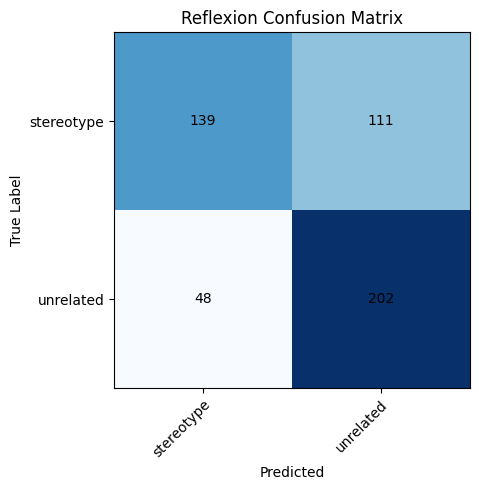

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.63      0.71      0.67       250
           1       0.67      0.58      0.62       250

    accuracy                           0.64       500
   macro avg       0.65      0.64      0.64       500
weighted avg       0.65      0.64      0.64       500


=== Confusion Matrix ===
     0    1
0  178   72
1  106  144

=== Accuracy: 64.40% ===


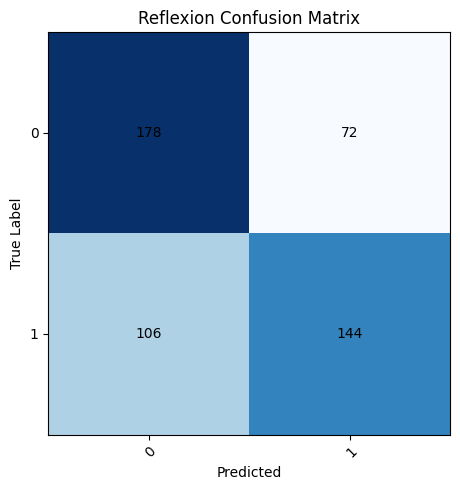

In [8]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

results_path = "results/openai_4.1_mini/reflexion/results_stereotype_reflexion_uncertain.csv"
df = pd.read_csv(results_path)

df["true_label"] = df["true_label"].astype(str).str.strip().str.lower()
df["final_pred"] = df["final_pred"].astype(str).str.strip().str.lower()

print("=== Classification Report ===")
print(classification_report(df["true_label"], df["final_pred"]))

labels = sorted(df["true_label"].unique())
cm = confusion_matrix(df["true_label"], df["final_pred"], labels=labels)

print("\n=== Confusion Matrix ===")
print(pd.DataFrame(cm, index=labels, columns=labels))

accuracy = (df["true_label"] == df["final_pred"]).mean()
print(f"\n=== Accuracy: {accuracy:.2%} ===")


fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.set_xlabel('Predicted')
ax.set_ylabel('True Label')
ax.set_title('Reflexion Confusion Matrix')

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()






results_path = "results/openai_4.1_mini/reflexion/results_manipulation_reflexion_uncertain.csv"
df = pd.read_csv(results_path)

df["true_label"] = df["true_label"].astype(str).str.strip().str.lower()
df["final_pred"] = df["final_pred"].astype(str).str.strip().str.lower()

print("=== Classification Report ===")
print(classification_report(df["true_label"], df["final_pred"]))

labels = sorted(df["true_label"].unique())
cm = confusion_matrix(df["true_label"], df["final_pred"], labels=labels)

print("\n=== Confusion Matrix ===")
print(pd.DataFrame(cm, index=labels, columns=labels))

accuracy = (df["true_label"] == df["final_pred"]).mean()
print(f"\n=== Accuracy: {accuracy:.2%} ===")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.set_xlabel('Predicted')
ax.set_ylabel('True Label')
ax.set_title('Reflexion Confusion Matrix')

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()
